# Spectrum Adapted EM algorithmによるスペクトルデータフィット
このノートは、pythonコードであるSEMPeaksの利用法に関するチュートリアルです。
このパッケージは、スペクトルデータを混合ガウス分布でフィッティングするためのツールです。
 
フィッティングにはスペクトル解析用EMアルゴリズム[Sci. Tech. Adv. Mater. 20, 733-735 (2019)]を用います。
verson2では、混合ガウス分布に加えて混合ローレンツ分布, 混合擬フォークト分布, 混合Doniach-Sunijic分布に対応しました。
詳しくは[STAM-M, in press.]を参考にしてください。
通常のEMアルゴリズムをこの問題に適用する場合、
データはn番目のイベントでの観測エネルギー$E_n$に対する集合$E_{\rm 1D}=\{E_n\}_{n=1}^{N}$を用いますが、
スペクトル解析用では$E_{\rm 1D}$をヒストグラム形式にしたデータ
$E_{\rm 2D} = \{E^{\rm bin}_n, w_n\}_{n=1}^{N_{\rm bin}}$を用います。
ただし、$E_n^{\rm bin}$はチャネル$n$のエネルギー値, $w_n$はチャネル$n$の重み, $N_{\rm bin}$はチャネル数です。
そのため入力であるデータファイルは、ndarray (2, n)形式（ndarray([[energy],[weight]])）である必要があります。

混合ガウス分布の成分数Kはデフォルトでは２ですが、任意の正の整数に設定することができます。
このチュートリアルでは、テストデータとして2成分混合ガウス分布から生成したダミーデータと、C1s に関するXPSデータを用意してます。

## チュートリアルの内容
0. パッケージのインストール
1. パッケージのimportとダミーデータ生成
2. 通常のEMアルゴリズムによるデータフィッティング時間
3. Spectrum-Adapted EM Algorithmによるデータフィッティング
4. フィッティングサマリーの表示
5. XPSデータのフィッティング

## 0. パッケージのインストールとパス設定
本パッケージは、PyPIにアップロードされいるため、`pip`コマンドでシステムに導入することができます。
`$pip install EMPeaks`

もしインストールがうまくいかない場合、もしくは直接モジュールにパスを通したい場合には、以下の手順をふんでください。
   1. 配布パッケージの中にあるEMPeaksフォルダをモジュール置き場に移してください。
   2. モジュール置き場のフルパスを記録してください。<br>
     （参照：mac: https://aprico-media.com/posts/1578/ ,windows: https://windows-podcast.com/sundayprogrammer/archives/80 ）
   3. jupyter notebookで以下のセルを実行してください（setup.pyを使った場合には不要です。）
      ``` python
         import sys
         sys.path.append("フルパス")
      ```
Windowsの場合、パス区切りがバックスラッシュ"\\"で表示されます。バックスラッシュはエスケープされてしまうため、全てスラッシュ"/"で置き換えてください。これでも問題なく読み込みます。

これで本パッケージを使用する準備が整いました。

## テスト1. Lorentzian Mixture Model(LMM によるフィッティング

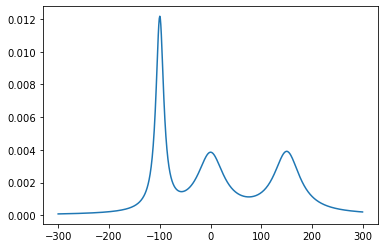

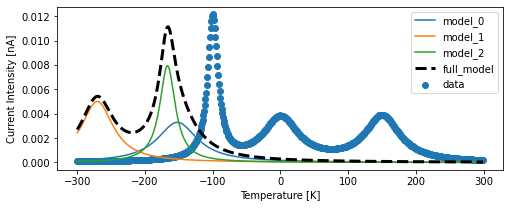

* Starting Trial #   0
<< Starting TSDC fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter.  37, elapsed time  0.71 s
   LogLikelihood:     -5.89564060e+00
        residual:      1.40254272e-10
<< Optimizing normalization factor by using least square method. >>
init 1.0
   non-linear least-square optimization is successfully finished.
            RMSE:      1.085483e-06
    Elapsed time:      1.934052e-03 s

* Starting Trial #   1
<< Starting TSDC fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter.  39, elapsed time  0.65 s
   LogLikelihood:     -5.89542618e+00
        residual:      9.36861815e-10
<< Optimizing normalization factor by using least square method. >>
init 1.0
   non-linear least-square optimization is successfully finished.
            RMSE:      2.709112e-06
    Elapsed time:      3.300905e-03 s

* Starting Trial #   2
<< Starting TSDC fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter.  55, elapsed time  1.12 s
   L

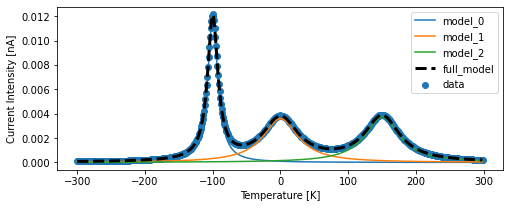

In [35]:
%matplotlib inline
from EMPeaks import LorentzianMixture
import numpy as np
import matplotlib.pyplot as plt
lmm_data = LorentzianMixture.LorentzianMixtureModel(K=3)
lmm_data.model[0].x0 =-100
lmm_data.model[1].x0 = 150
lmm_data.model[2].x0 = 0

x = np.arange(-300, 300)
y = lmm_data.predict(x)
plt.plot(x,y)

lmm = LorentzianMixture.LorentzianMixtureModel(K=3)
lmm.plot(x,y)

lmm.sampling(x,y,trial=5, r_eps=1e-9)
lmm.plot(x,y)

## 2. Spectrum-adapted EMアルゴリズムによるフィッティング

-- test_data information ---
model:               Gaussian mixture model of K = 2
mu(means):           [3.5 6.5]
sigma^2(variances):  [1.4 0.7]
pi(mixing ratio):    [0.3 0.7]
n(data number):      50000
bins:                500


---data2D---
shape:  (2, 500)
initial param: [{'mu': 0.4818478443380165, 'sigma': 0.7580751412046036, 'pi': 0.24676709048758128}, {'mu': 4.262236975674479, 'sigma': 0.6015373513500547, 'pi': 0.7532329095124187}]

**** Sampling: 0 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 148
Log Likelihood:  -90068.7583930459

-- Converged parameters --
mu(means):          [3.4604996  6.47561706]
sigma^2(variance):  [1.32913467 0.70356382]
pi(mixing ratio):   [0.29342694 0.70657306]

**** Sampling: 1 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 226
Log Likelihood:  -90068.75839304583

-- Converged parameters --
mu(means):          [3.46049957 6.47561705]
sigma^2(variance):

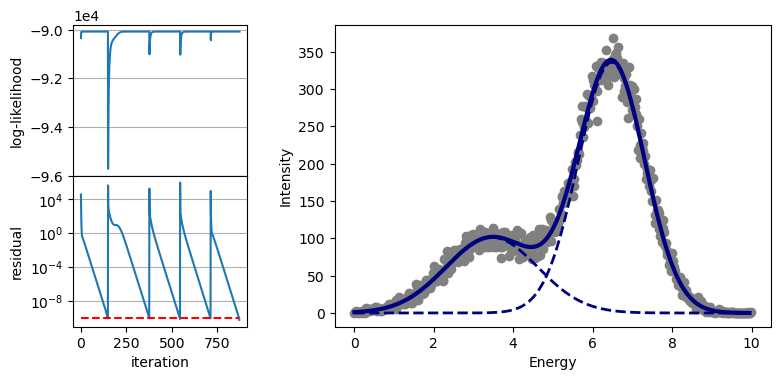

In [2]:
%time test.test_spectrum_adapted_em(N=50000,sampling=5)

## 3. XPS 実験データに対するフィッティング
EMPeaks_1.0.0にあるGFET0126_25V_C1s.txtといるファイルをこのjupyter notebookのあるフォルダに移してから次のコマンドを実行してください。

initial param: [{'mu': 705.1606762298503, 'sigma': 0.49498709261434637, 'pi': 0.3111131629623294}, {'mu': 714.2848176155949, 'sigma': 0.6202670169414987, 'pi': 0.2835191310343102}, {'mu': 706.0003848292055, 'sigma': 0.7408968665523505, 'pi': 0.4053677060033604}]

**** Sampling: 0 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 391
Log Likelihood:  -13164444.119688604

-- Converged parameters --
mu(means):          [704.60433492 711.30085593 712.90420869]
sigma^2(variance):  [31.59613356  1.82789958  0.3494288 ]
pi(mixing ratio):   [0.43866543 0.10422409 0.45711047]

**** Sampling: 1 ****
Start Fitting by Spectrum-adapted EM algorithm.

Log Likelihood is converged with iteration 382
Log Likelihood:  -13164444.119688604

-- Converged parameters --
mu(means):          [704.60433522 711.30086065 712.9042089 ]
sigma^2(variance):  [31.59613165  1.82789929  0.3494285 ]
pi(mixing ratio):   [0.43866547 0.10422435 0.45711018]

**** Sampling: 2 ***

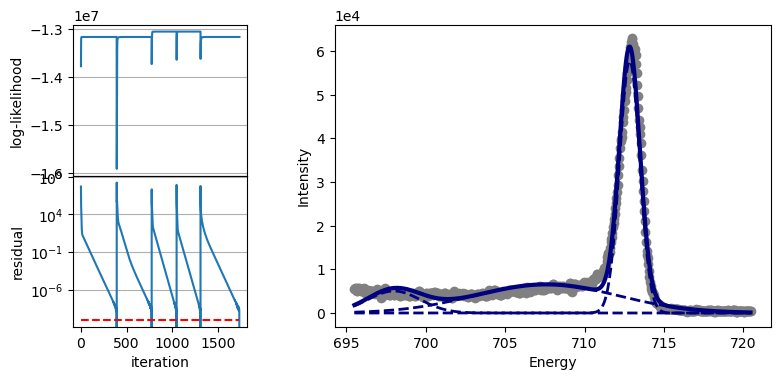

In [3]:
fpath = 'GFET0126_25V_C1s.txt'
%time test.test_exp_data(file=fpath, sampling=5)

[markdownへの埋め込み例]
記法：`<div class="pull-left">![Animated GIF](test.gif) <div>`
<div class="pull-left">![Animated GIF](ani_gmm_history.gif) <div>
